# WITHOUT JAX

/tmp/ipykernel_73449/2575358161.py:19: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  train_data['Age'].fillna(train_data['Age'].mean(), inplace=True)
/tmp/ipykernel_73449/2575358161.py:20: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace m

Epoch 0, Loss: 0.6931
Epoch 200, Loss: 0.4488
Epoch 400, Loss: 0.4457
Epoch 600, Loss: 0.4453
Epoch 800, Loss: 0.4453

Training Time (NumPy): 0.1228 seconds
Sample Predictions: [[0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [1]
 [0]
 [1]
 [0]]


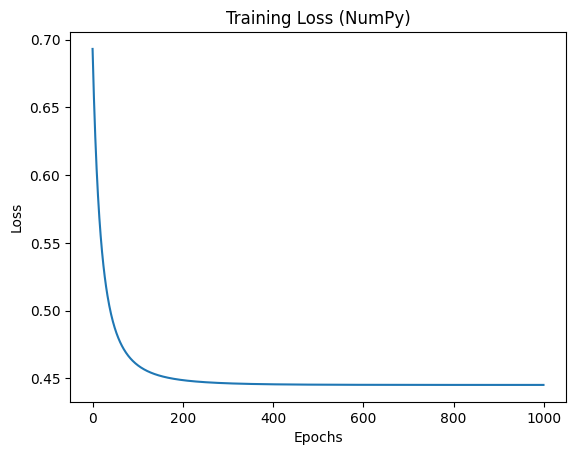

In [1]:
import pandas as pd
import numpy as np
import time
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# -------------------------
# Load your datasets
# -------------------------
train_data = pd.read_csv("train.csv")
test_data = pd.read_csv("test.csv")

# -------------------------
# Preprocessing
# -------------------------
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']

# Fill missing values
train_data['Age'].fillna(train_data['Age'].mean(), inplace=True)
test_data['Age'].fillna(train_data['Age'].mean(), inplace=True)

# Encode categorical
train_data['Sex'] = train_data['Sex'].map({'male': 0, 'female': 1})
test_data['Sex'] = test_data['Sex'].map({'male': 0, 'female': 1})

# Drop rows with missing values
train_data = train_data.dropna(subset=features + ['Survived'])

# Extract X and y
X_train = train_data[features].values
y_train = train_data['Survived'].values.reshape(-1, 1)

X_test = test_data[features].fillna(0).values

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -------------------------
# Logistic Regression
# -------------------------
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def loss(y, y_pred):
    eps = 1e-7
    return -np.mean(y * np.log(y_pred + eps) + (1 - y) * np.log(1 - y_pred + eps))

# Initialize
W = np.zeros((X_train.shape[1], 1))
b = 0

lr = 0.1
epochs = 1000

# -------------------------
# Training
# -------------------------
start = time.time()
loss_history = []

for i in range(epochs):
    z = np.dot(X_train, W) + b
    y_pred = sigmoid(z)

    dz = y_pred - y_train
    dW = np.dot(X_train.T, dz) / len(X_train)
    db = np.mean(dz)

    W -= lr * dW
    b -= lr * db

    current_loss = loss(y_train, y_pred)
    loss_history.append(current_loss)

    if i % 200 == 0:
        print(f"Epoch {i}, Loss: {current_loss:.4f}")

end = time.time()

print("\nTraining Time (NumPy):", round(end - start, 4), "seconds")

# -------------------------
# Predictions
# -------------------------
y_pred_test = sigmoid(np.dot(X_test, W) + b)
y_pred_labels = (y_pred_test > 0.5).astype(int)

print("Sample Predictions:", y_pred_labels[:10])

import matplotlib.pyplot as plt

plt.figure()
plt.plot(loss_history)
plt.title("Training Loss (NumPy)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

# WITH JAX

Epoch 0, Loss: 0.6805
Epoch 200, Loss: 0.4453
Epoch 400, Loss: 0.4429
Epoch 600, Loss: 0.4426
Epoch 800, Loss: 0.4426

Training Time (JAX): 1.0862 seconds
Sample Predictions: [[0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [1]
 [0]
 [1]
 [0]]


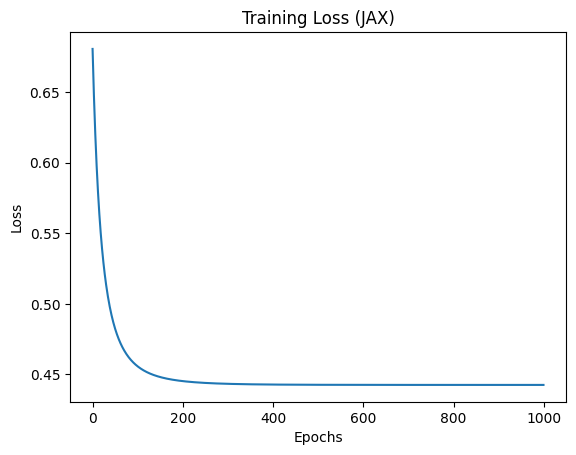

In [5]:
import pandas as pd
import numpy as np
import time

import jax.numpy as jnp
from jax import grad, jit, vmap

from sklearn.preprocessing import StandardScaler

# -------------------------
# Load data
# -------------------------
train_data = pd.read_csv("train.csv")
test_data = pd.read_csv("test.csv")

# -------------------------
# Preprocessing (FIXED warning)
# -------------------------
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']

# Fix chained assignment issue
train_data['Age'] = train_data['Age'].fillna(train_data['Age'].mean())
test_data['Age'] = test_data['Age'].fillna(train_data['Age'].mean())

train_data['Sex'] = train_data['Sex'].map({'male': 0, 'female': 1})
test_data['Sex'] = test_data['Sex'].map({'male': 0, 'female': 1})

train_data = train_data.dropna(subset=features + ['Survived'])

# Extract features
X_train = train_data[features].values
y_train = train_data['Survived'].values.reshape(-1, 1)

X_test = test_data[features].fillna(0).values

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert to JAX arrays
X_train = jnp.array(X_train)
y_train = jnp.array(y_train)
X_test = jnp.array(X_test)

# -------------------------
# Model
# -------------------------
def sigmoid(z):
    return 1 / (1 + jnp.exp(-z))

def predict(W, b, X):
    return sigmoid(jnp.dot(X, W) + b)

# -------------------------
# Loss function
# -------------------------
def loss_fn(W, b, X, y):
    y_pred = predict(W, b, X)
    eps = 1e-7
    return -jnp.mean(y * jnp.log(y_pred + eps) + (1 - y) * jnp.log(1 - y_pred + eps))

# -------------------------
# Gradients
# -------------------------
grad_fn = grad(loss_fn, argnums=(0, 1))

# -------------------------
# Vectorized prediction (vmap)
# -------------------------
batched_predict = vmap(lambda x, W, b: sigmoid(jnp.dot(x, W) + b), in_axes=(0, None, None))

# -------------------------
# JIT compile training step
# -------------------------
@jit
def update(W, b, X, y, lr):
    dW, db = grad_fn(W, b, X, y)
    W = W - lr * dW
    b = b - lr * db
    return W, b

# -------------------------
# Initialize
# -------------------------
W = jnp.zeros((X_train.shape[1], 1))
b = 0.0

lr = 0.1
epochs = 1000

# -------------------------
# Training
# -------------------------
start = time.time()
loss_history = []

for i in range(epochs):
    W, b = update(W, b, X_train, y_train, lr)
    
    current_loss = loss_fn(W, b, X_train, y_train)
    loss_history.append(current_loss)
    
    if i % 200 == 0:
        print(f"Epoch {i}, Loss: {current_loss:.4f}")

end = time.time()

print("\nTraining Time (JAX):", round(end - start, 4), "seconds")

# -------------------------
# Predictions (fast batch using vmap)
# -------------------------
y_pred_test = batched_predict(X_test, W, b)
y_pred_labels = (y_pred_test > 0.5).astype(int)

print("Sample Predictions:", y_pred_labels[:10])

import matplotlib.pyplot as plt

plt.figure()
plt.plot(loss_history)
plt.title("Training Loss (JAX)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()